In [1]:
import os
import sys
#sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))
#from util.filter_data import filtering

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
import seaborn as sns

Filtering

In [2]:
df_original=pd.read_csv('/Users/takac/machinelearning/machine-n-learnings-inc/src/claims_train.csv')
#Since the density is the continiuous variable, we can drop the Area column
df_original.drop('Area', axis=1, inplace=True)
#Rescale BonusMalus, since in the literature it is said to be between 0.5 and 3.5
df_original['BonusMalus']=df_original['BonusMalus']/100
#Filtering the Exposure since it goes out of bounds (0-1)
df = df_original[df_original['Exposure']<=1]
#Filterig VehAge to be less than 25, since on the roads these are the most common vehicles
df = df[(df['VehAge']<=25)]


regions_remove_outliers = ['R25','R82','R54','R94','R93','R91','R52',
                            'R72','R31','R73','R23','R22','R41','R42',
                            'R83','R21','R74','R43', 'R11']

def remove_outliers_selective(group):
    # Only remove outliers for regions in the list
    if group.name in regions_remove_outliers:
        q1, q3 = group['Density'].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        return group[(group['Density'] >= lower) & (group['Density'] <= upper)]
    else:
        return group

df = df.groupby('Region', group_keys=False).apply(remove_outliers_selective)

min_malus = 0.95 ** (df['DrivAge']-18)
bad_mal_mask = df['BonusMalus'] >= min_malus
age_avg = df[bad_mal_mask].groupby('DrivAge')['BonusMalus'].mean()
impossible_malus_mask = df['BonusMalus']<0.95**(df['DrivAge']-18)
df.loc[impossible_malus_mask, 'BonusMalus'] = df.loc[impossible_malus_mask, 'DrivAge'].map(age_avg)

alpha=2 # If we want to penaltize the claimnb more
beta=0 # If we want to finetune the exposure part 
gamma=0.1 # To avoid log(0)
df['Risk'] = (np.log(1+(gamma+df['ClaimNb']**alpha)/(df['Exposure']+beta))/(1+(np.log(1+(gamma+df['ClaimNb']**alpha)/(df['Exposure']+beta)))))

(541416, 11)
(539373, 11)
(507508, 11)


C:\Users\takac\AppData\Local\Temp\ipykernel_25564\722243527.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Region', group_keys=False).apply(remove_outliers_selective)


Separating Data into numerical and categorical

In [3]:
df_clean = df.drop(columns=["IDpol","ClaimNb", "Exposure","Region","Risk"])
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns

Scaling Data for PCA

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[numeric_cols])

Running the PCA on the Data

In [5]:
pca = PCA(n_components=0.9, svd_solver='full')
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (507508, 5)
Reduced shape: (507508, 4)


Plotting the PCA

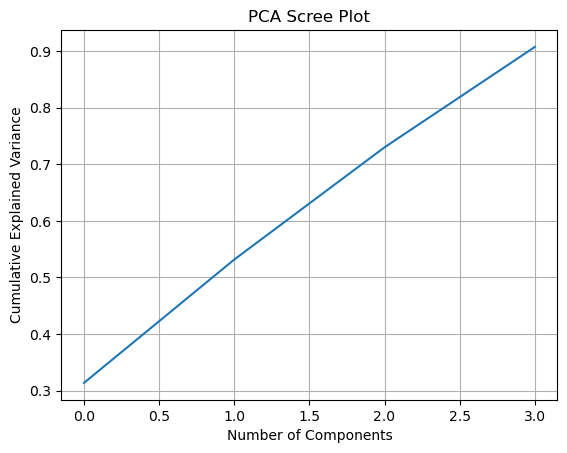

In [6]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.show()

Cleaning the data for Clustering

In [7]:
X_cat = pd.get_dummies(df_clean[categorical_cols], drop_first=True)
X_final = np.hstack([X_pca, X_cat.values])
X_final.shape

(507508, 15)

Clustering

In [8]:
# scores = []
# for k in tqdm(range(2, 10), desc="Evaluating KMeans for different k"):
#     km = KMeans(n_clusters=k, random_state=42,)
#     labels = km.fit_predict(X_final)
#     score = silhouette_score(X_final, labels)
#     scores.append((k, score))

# best_k = max(scores, key=lambda x: x[1])[0]
# print("Best k by silhouette score:", best_k)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_final)

df["Cluster"] = clusters

Plotting Clustering

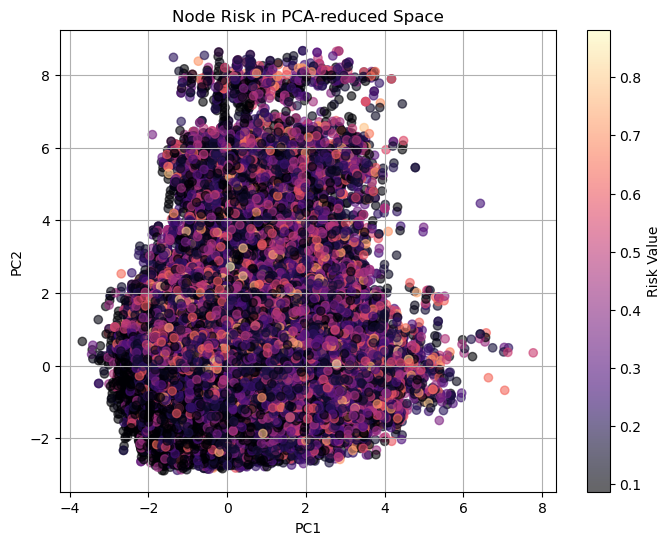

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Risk"], cmap="magma", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Node Risk in PCA-reduced Space")
plt.colorbar(label="Risk Value")
plt.grid(True)
plt.show()

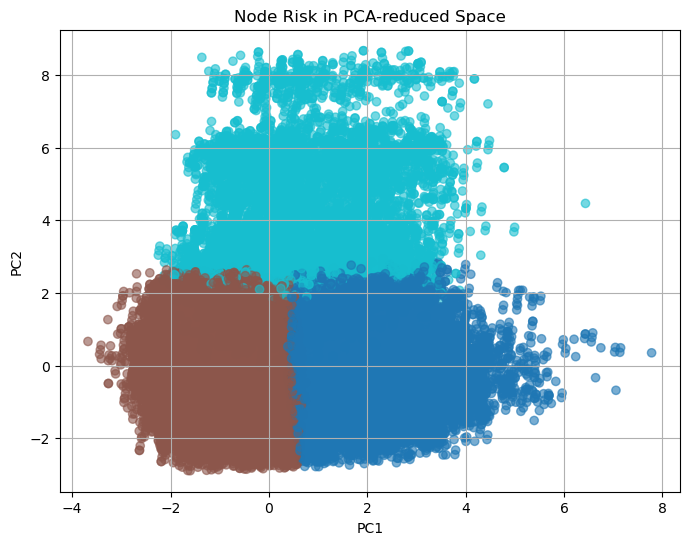

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"], cmap="tab10", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Node Risk in PCA-reduced Space")
plt.grid(True)
plt.show()

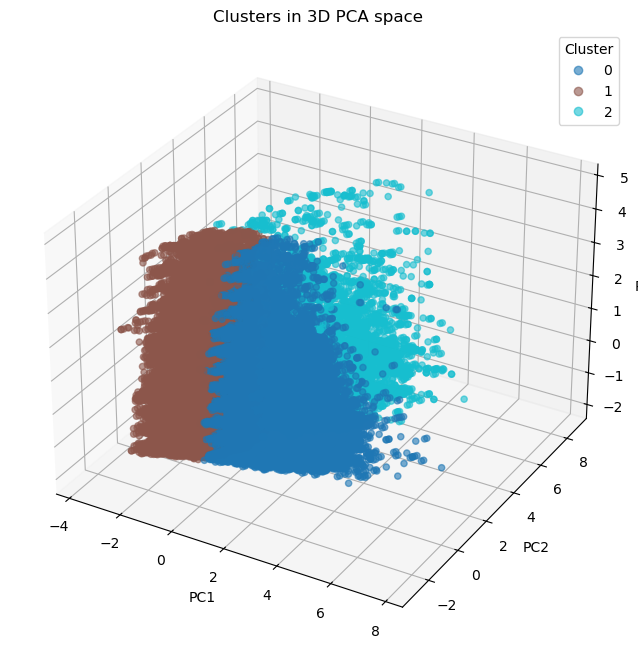

In [11]:
# 3D scatterplot using first three principal components
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter( X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=df["Cluster"], cmap="tab10", alpha=0.6)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Clusters in 3D PCA space")

plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

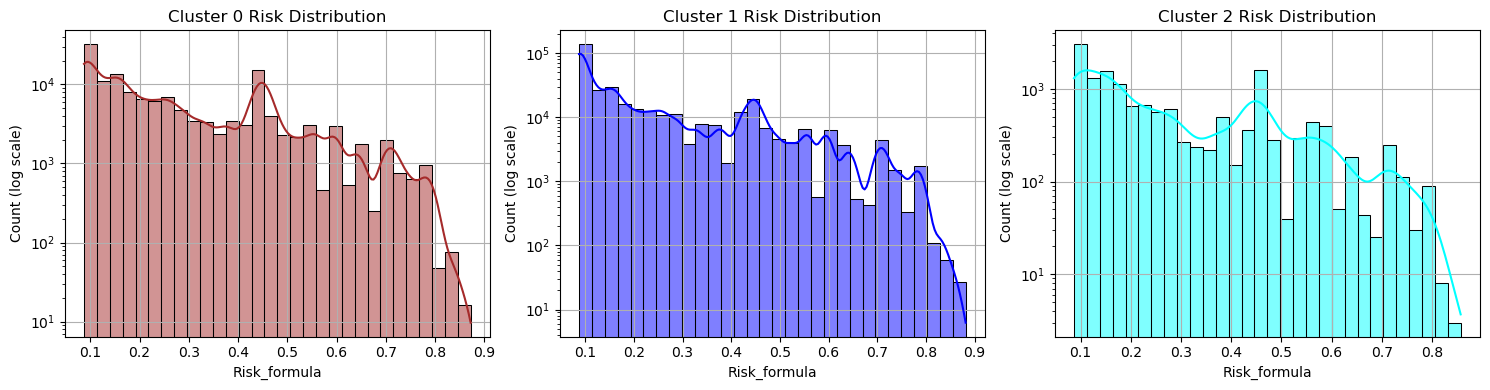

In [12]:
clusters = sorted(df["Cluster"].unique())
colors = ["brown", "blue", "cyan"]

plt.figure(figsize=(15, 4))
for i, cluster in enumerate(clusters):
    plt.subplot(1, len(clusters), i + 1)
    sns.histplot(
        df[df["Cluster"] == cluster]["Risk"],
        bins=30,
        kde=True,
        color=colors[i]
    )
    plt.title(f"Cluster {cluster} Risk Distribution")
    plt.xlabel("Risk_formula")
    plt.ylabel("Count (log scale)")
    plt.yscale("log")
    plt.grid(True)

plt.tight_layout()
plt.show()

Printing counts of Clusters

In [13]:
print(df["Cluster"].value_counts())

Cluster
1    350514
0    141943
2     15051
Name: count, dtype: int64
